<a href="https://colab.research.google.com/github/JonGarmon/urban-cooling-spitalfields/blob/main/Toynbee_Street_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install folium pandas matplotlib seaborn

🚀 Starting Unified Urban Cooling Analysis...
✅ Data loaded successfully.
📊 Generating Social Impact Correlations...
📈 Generating Cooling Impact Forecast...
🗺️ Generating Snapped Intervention Map...
✅ Map perfectly aligned with White's Row and Wentworth St.


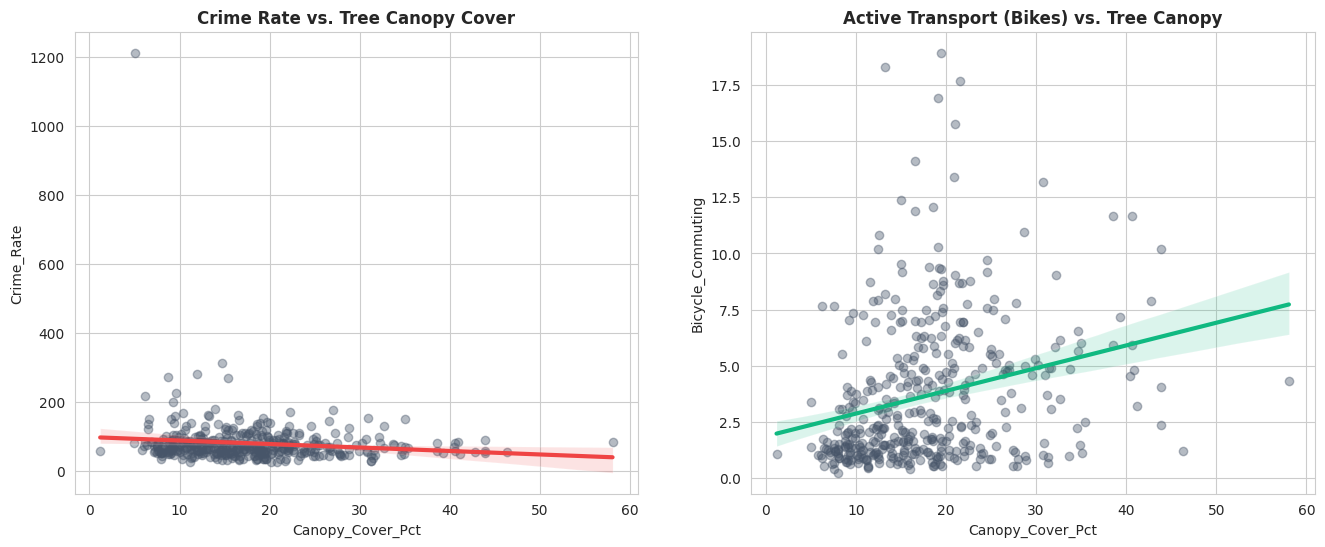

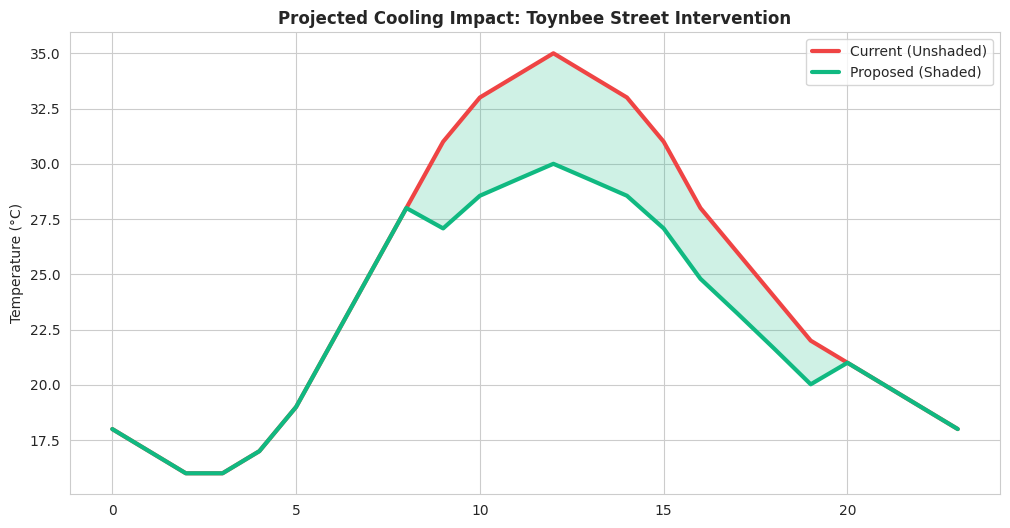

In [15]:
# ==========================================
# 1. SETUP & DATA ANALYSIS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins

print("🚀 Starting Unified Urban Cooling Analysis...")

# Load core datasets targeting correct sheets
try:
    canopy_df = pd.read_excel('/content/drive/MyDrive/Rancho - 31 Toynbee Street/2026_Urban_Cooling_Tree_Planting/2024_tree_canopy_borough_ward_stats.xlsx', sheet_name='Ward')
    ward_data = pd.read_excel('/content/drive/MyDrive/Rancho - 31 Toynbee Street/2026_Urban_Cooling_Tree_Planting/ward-profiles-excel-version.xls', sheet_name='Data')
    print("✅ Data loaded successfully.")
except Exception as e:
    print(f"❌ Error loading data: {e}. Ensure files are uploaded to Colab.")

# Clean Ward Names for Merging
ward_data['Ward name clean'] = ward_data['Ward name'].str.split(' - ').str[-1].str.strip()
canopy_df['Ward name clean'] = canopy_df['ward'].str.strip()

# Merge
df_merged = pd.merge(canopy_df, ward_data, on='Ward name clean', how='inner')

# Identify Columns Dynamically
crime_col = [col for col in df_merged.columns if 'Crime rate' in col][0]
bike_col = [col for col in df_merged.columns if 'bicycle to work' in col][0]

# Prep Numerical Data
df_merged['Canopy_Cover_Pct'] = df_merged['percentage'] * 100
df_merged['Crime_Rate'] = pd.to_numeric(df_merged[crime_col], errors='coerce')
df_merged['Bicycle_Commuting'] = pd.to_numeric(df_merged[bike_col], errors='coerce')
df_merged.dropna(subset=['Canopy_Cover_Pct', 'Crime_Rate', 'Bicycle_Commuting'], inplace=True)

# ==========================================
# 2. GENERATE PORTFOLIO VISUALS (PNGs)
# ==========================================
print("📊 Generating Social Impact Correlations...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")
sns.regplot(x='Canopy_Cover_Pct', y='Crime_Rate', data=df_merged, ax=ax1,
            scatter_kws={'alpha':0.4, 'color':'#475569'}, line_kws={'color':'#EF4444', 'linewidth':3})
ax1.set_title('Crime Rate vs. Tree Canopy Cover', fontweight='bold')
sns.regplot(x='Canopy_Cover_Pct', y='Bicycle_Commuting', data=df_merged, ax=ax2,
            scatter_kws={'alpha':0.4, 'color':'#475569'}, line_kws={'color':'#10B981', 'linewidth':3})
ax2.set_title('Active Transport (Bikes) vs. Tree Canopy', fontweight='bold')
plt.savefig('social_impact_correlation.png', dpi=300)

print("📈 Generating Cooling Impact Forecast...")
h_range = np.arange(0, 24)
temp_unshaded = [18,17,16,16,17,19,22,25,28,31,33,34,35,34,33,31,28,26,24,22,21,20,19,18]
temp_shaded = [t - (5 * (t/35)**2) if 9 <= h <= 19 else t for h, t in zip(h_range, temp_unshaded)]
plt.figure(figsize=(12, 6))
plt.plot(h_range, temp_unshaded, color='#EF4444', label='Current (Unshaded)', linewidth=3)
plt.plot(h_range, temp_shaded, color='#10B981', label='Proposed (Shaded)', linewidth=3)
plt.fill_between(h_range, temp_unshaded, temp_shaded, color='#10B981', alpha=0.2)
plt.title('Projected Cooling Impact: Toynbee Street Intervention', fontweight='bold')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.savefig('projected_cooling_impact.png', dpi=300)

# ==========================================
# 3. INTERACTIVE SPATIAL PLANNING (SNAPPED)
# ==========================================
print("🗺️ Generating Snapped Intervention Map...")

# 1. Final Aligned Path
# North Anchor: White's Row | South Anchor: Wentworth St
toynbee_path = [
    [51.518332726043184, -0.07451220882674457], # North Entrance
    [51.51800696825174, -0.07448625137133927], # Brune Street
    [51.516923336501854, -0.07416641088654082]  # South Entrance
]

# 2. Initialize Map
m = folium.Map(location=toynbee_path[1], zoom_start=19, tiles='OpenStreetMap')

# 3. Draw the Street Layer
folium.PolyLine(
    toynbee_path,
    color='#EF4444',
    weight=12,
    opacity=0.6,
    tooltip="Toynbee Street - Cooling Intervention"
).add_to(m)

# 4. Generate 14 Tree Pits Aligned to the Path
def get_segment_points(p1, p2, num):
    return np.array([np.linspace(p1[0], p2[0], num), np.linspace(p1[1], p2[1], num)]).T

# Distribute 14 tree pits across the two segments of the path proportionally to their lengths.
# Segment 1 (White Row to Brune Street): 37.39 m
# Segment 2 (Brune Street to Wentworth Street): 123.06 m
# Total length = 37.39 + 123.06 = 160.45 m

# We want 14 unique tree pits in total.
# Consider distributing 13 'intervals' (14 points = 13 intervals).

# Number of intervals for segment 1 (White Row to Brune Street)
num_intervals_north = int(round(13 * (37.39 / 160.45))) # approx 3 intervals
# Number of points = intervals + 1 (including start and end of segment)
num_pts_north = num_intervals_north + 1 # 4 points including White Row and Brune Street

# Number of intervals for segment 2 (Brune Street to Wentworth Street)
num_intervals_south = 13 - num_intervals_north # approx 10 intervals
# Number of points = intervals + 1 (including start and end of segment)
num_pts_south = num_intervals_south + 1 # 11 points including Brune Street and Wentworth Street

# Generate points for each segment
pts_north = get_segment_points(toynbee_path[0], toynbee_path[1], num_pts_north)
pts_south = get_segment_points(toynbee_path[1], toynbee_path[2], num_pts_south)

# Combine points, avoiding duplicate at Brune Street (toynbee_path[1])
all_tree_points = np.vstack([pts_north, pts_south[1:]])

for i, coord in enumerate(all_tree_points):
    folium.CircleMarker(
        location=coord,
        radius=6,
        color='#10B981',
        fill=True,
        fill_opacity=1,
        tooltip=f"Proposed Pit #{i+1} (Norway Maple)"
    ).add_to(m)

# 5. Add Heatmap Layer
heat_data = [[c[0], c[1], 0.8] for c in all_tree_points]
folium.plugins.HeatMap(heat_data, radius=30, blur=18, min_opacity=0.3).add_to(m)

# Save and Show
m.save("Toynbee_Street_Map.html")
print("✅ Map perfectly aligned with White's Row and Wentworth St.")
m